# 01 - Exploratory Data Analysis: CatMeows

What is actually in this dataset, and what does it imply for modelling?

The dataset is [CatMeows](https://doi.org/10.5281/zenodo.4008297) (Ludovico, Ntalampiras,
Presti, Cannas, Battini & Mattiello, 2020): 440 vocalizations from 21 cats, recorded at
8 kHz in three staged contexts.

Run `python src/download_data.py` first if `data/raw/` is empty.

**The single most important number below is not a distribution — it is `21`.**
That is how many cats there are, and it is the constraint that governs every modelling
decision in this repository.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work whether the notebook is launched from repo root or from notebooks/.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))
DATA_DIR = REPO_ROOT / "data" / "raw"

from features import (
    CONTEXT_LABELS,
    build_dataset_frame,
    load_wav,
    log_mel_spectrogram,
    spectral_centroid,
)

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 110

assert DATA_DIR.exists(), f"{DATA_DIR} missing - run: python src/download_data.py"
print("data dir:", DATA_DIR)

data dir: F:\test\MeowSense\data\raw


## Load metadata

Every field below is parsed out of the *filename* — the dataset encodes context, cat ID,
breed, sex and owner directly in the name (see `src/features.py`).

In [2]:
df = build_dataset_frame(DATA_DIR)
print(f"{len(df)} recordings | {df.cat_id.nunique()} cats | {df.owner_id.nunique()} owners")
print(f"sample rates present: {sorted(df.source_sr.unique())}")
df.head()

F:\test\MeowSense\src\features.py:237: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(rec.path)


440 recordings | 21 cats | 12 owners
sample rates present: [np.int64(8000)]


,path,context,context_label,cat_id,breed,breed_label,sex,sex_label,is_female,is_neutered,owner_id,session,counter,duration_s,source_sr
0,F:\test\MeowSense\data\raw\B_ANI01_MC_FN_SIM01...,B,brushing,ANI01,MC,Maine Coon,FN,female neutered,True,True,SIM01,1,1,2.281500,8000
1,F:\test\MeowSense\data\raw\B_ANI01_MC_FN_SIM01...,B,brushing,ANI01,MC,Maine Coon,FN,female neutered,True,True,SIM01,1,2,1.419000,8000
2,F:\test\MeowSense\data\raw\B_ANI01_MC_FN_SIM01...,B,brushing,ANI01,MC,Maine Coon,FN,female neutered,True,True,SIM01,1,3,1.798875,8000
3,F:\test\MeowSense\data\raw\B_ANI01_MC_FN_SIM01...,B,brushing,ANI01,MC,Maine Coon,FN,female neutered,True,True,SIM01,3,1,1.739500,8000
4,F:\test\MeowSense\data\raw\B_ANI01_MC_FN_SIM01...,B,brushing,ANI01,MC,Maine Coon,FN,female neutered,True,True,SIM01,3,2,1.268000,8000


## Context distribution

The target variable. It is imbalanced, which fixes our baseline: always guessing
`isolation` is right ~50% of the time. **Any model must beat that to be worth anything.**

context_label
isolation    221
brushing     127
food          92

majority-class baseline: 0.502


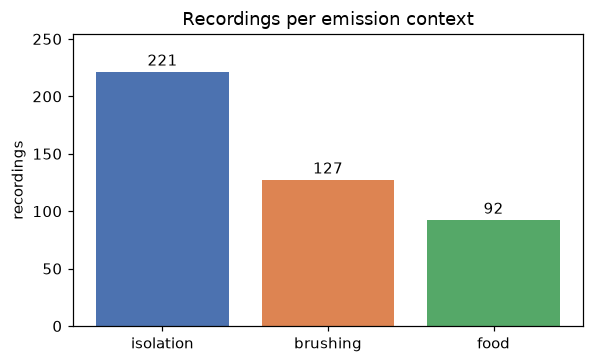

In [3]:
ctx = df.context_label.value_counts()
print(ctx.to_string())

majority = ctx.max() / len(df)
print(f"\nmajority-class baseline: {majority:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 3.4))
bars = ax.bar(ctx.index, ctx.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.bar_label(bars, padding=2)
ax.set_ylabel("recordings")
ax.set_title("Recordings per emission context")
ax.margins(y=0.15)
plt.tight_layout()

## Who are these cats?

Breed, sex and per-cat counts. Note how unevenly recordings are spread across cats —
this is why a random train/test split would be misleading.

breed_label
European Shorthair    252
Maine Coon            188

sex_label
female neutered    277
male neutered       76
female intact       68
male intact         19


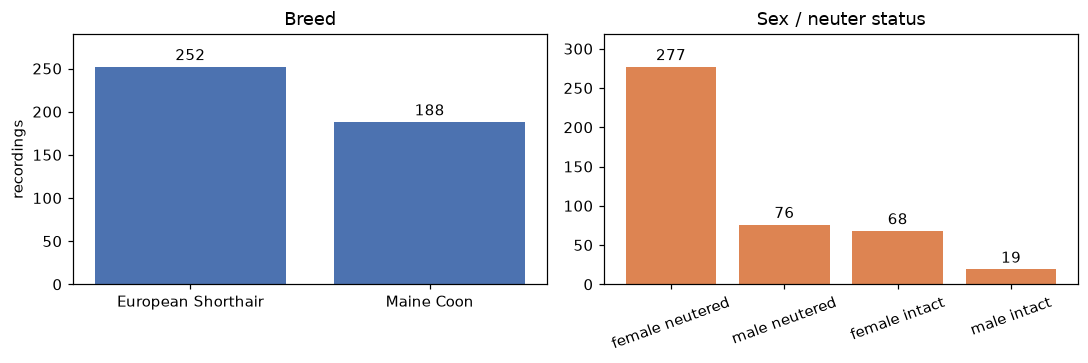

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

breed = df.breed_label.value_counts()
b1 = axes[0].bar(breed.index, breed.values, color="#4C72B0")
axes[0].bar_label(b1, padding=2)
axes[0].set_title("Breed")
axes[0].set_ylabel("recordings")
axes[0].margins(y=0.15)

sex = df.sex_label.value_counts()
b2 = axes[1].bar(sex.index, sex.values, color="#DD8452")
axes[1].bar_label(b2, padding=2)
axes[1].set_title("Sex / neuter status")
axes[1].tick_params(axis="x", rotation=20)
axes[1].margins(y=0.15)

plt.tight_layout()

print(breed.to_string())
print()
print(sex.to_string())

recordings per cat: min=5, median=19, max=54



cats missing at least one context: 11 / 21


context_label,brushing,food,isolation
cat_id,,,
ANI01,6,0,4
BAC01,6,12,7
BLE01,0,3,45
BRA01,7,2,10
BRI01,7,8,0
CAN01,26,2,26
CLE01,0,0,20
DAK01,4,4,32
IND01,11,10,0


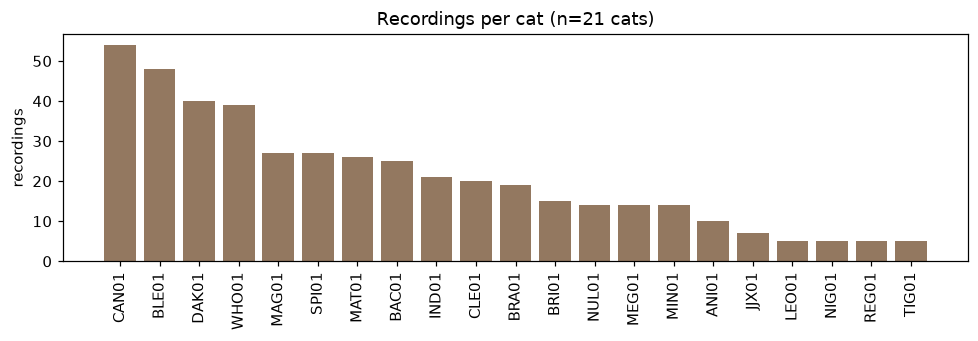

In [5]:
per_cat = df.groupby("cat_id").size().sort_values(ascending=False)
print(f"recordings per cat: min={per_cat.min()}, median={per_cat.median():.0f}, max={per_cat.max()}")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(per_cat.index, per_cat.values, color="#937860")
ax.set_ylabel("recordings")
ax.set_title(f"Recordings per cat (n={df.cat_id.nunique()} cats)")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()

# Not every cat contributes every context - another reason folds vary so much.
coverage = df.pivot_table(index="cat_id", columns="context_label", values="path", aggfunc="count").fillna(0).astype(int)
print(f"\ncats missing at least one context: {(coverage == 0).any(axis=1).sum()} / {len(coverage)}")
coverage

## Durations

Calls are short. This sets `CNN_N_FRAMES` in `src/features.py`: at a 16 ms hop, 128 frames
≈ 2.05 s, which comfortably covers the median call.

min=1.09s  median=1.81s  mean=1.83s  max=4.00s


,count,mean,50%,min,max
context_label,,,,,
brushing,127.0,1.845468,1.806250,1.106625,4.001500
food,92.0,1.641125,1.608437,1.085500,2.302875
isolation,221.0,1.901927,1.865500,1.221250,2.934625


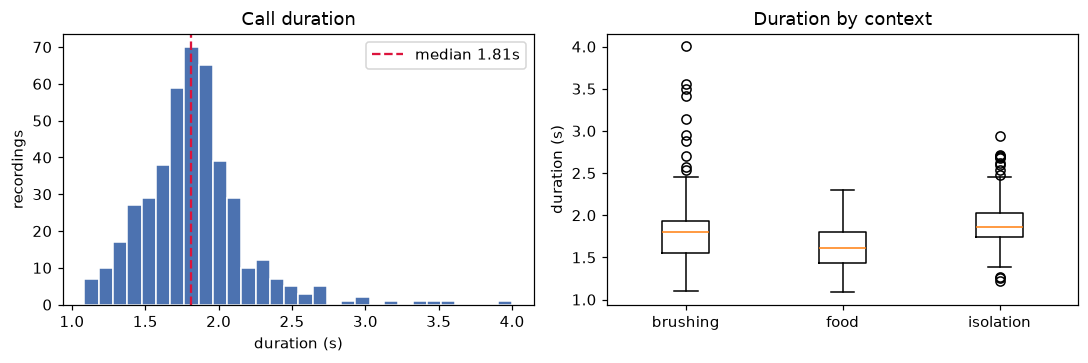

In [6]:
d = df.duration_s
print(f"min={d.min():.2f}s  median={d.median():.2f}s  mean={d.mean():.2f}s  max={d.max():.2f}s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(d, bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(d.median(), color="crimson", ls="--", label=f"median {d.median():.2f}s")
axes[0].set_xlabel("duration (s)")
axes[0].set_ylabel("recordings")
axes[0].set_title("Call duration")
axes[0].legend()

order = ["brushing", "food", "isolation"]
# NB: set tick labels explicitly rather than via boxplot(labels=...), which was
# renamed to tick_labels in matplotlib 3.9 and removed in 3.11.
axes[1].boxplot([df.loc[df.context_label == c, "duration_s"] for c in order])
axes[1].set_xticks(range(1, len(order) + 1))
axes[1].set_xticklabels(order)
axes[1].set_ylabel("duration (s)")
axes[1].set_title("Duration by context")

plt.tight_layout()

df.groupby("context_label").duration_s.describe()[["count", "mean", "50%", "min", "max"]]

## Spectral centroid by context

The spectral centroid is the "centre of mass" of the spectrum — a single interpretable
number for *how bright / high-pitched* a call sounds.

If the three contexts separated cleanly here, the task would be easy. Watch how much the
distributions overlap.

F:\test\MeowSense\src\features.py:261: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(str(path))


               count        mean         std          50%
context_label                                            
brushing       127.0  1322.24256  199.980425  1336.979214
food            92.0  1350.00343  164.247847  1352.847924
isolation      221.0  1342.78875  151.230526  1329.227369


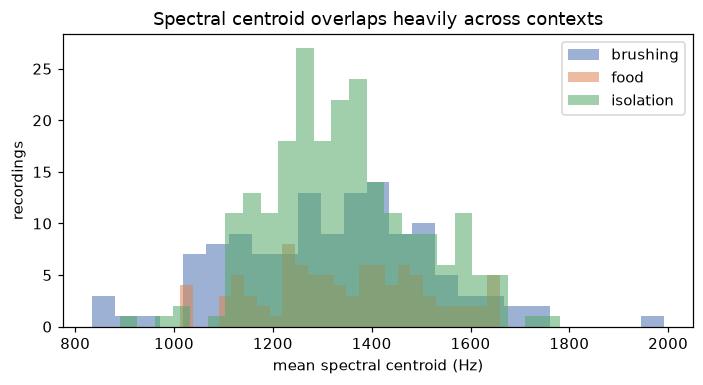

In [7]:
rows = []
for rec in df.itertuples():
    y, sr = load_wav(rec.path)
    rows.append({"context_label": rec.context_label, "centroid_hz": float(np.mean(spectral_centroid(y, sr)))})

cent = pd.DataFrame(rows)
print(cent.groupby("context_label").centroid_hz.describe()[["count", "mean", "std", "50%"]].to_string())

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for c, color in zip(order, ["#4C72B0", "#DD8452", "#55A868"]):
    ax.hist(cent.loc[cent.context_label == c, "centroid_hz"], bins=25, alpha=0.55, label=c, color=color)
ax.set_xlabel("mean spectral centroid (Hz)")
ax.set_ylabel("recordings")
ax.set_title("Spectral centroid overlaps heavily across contexts")
ax.legend()
plt.tight_layout()

## Example spectrograms

One example per context, using the exact log-mel settings the models consume
(8 kHz, `n_fft=256`, 40 mel bands, 50-4000 Hz).

F:\test\MeowSense\src\features.py:261: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(str(path))
F:\test\MeowSense\src\features.py:261: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(str(path))
F:\test\MeowSense\src\features.py:261: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sr, data = wavfile.read(str(path))


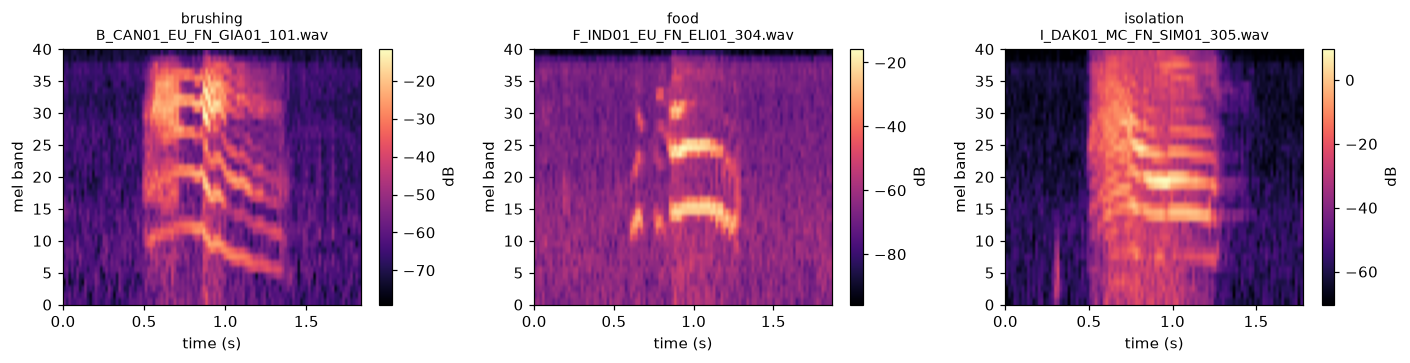

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, ctx_label in zip(axes, order):
    sample = df[df.context_label == ctx_label].sample(1, random_state=SEED).iloc[0]
    y, sr = load_wav(sample.path)
    S = log_mel_spectrogram(y, sr)
    im = ax.imshow(S, origin="lower", aspect="auto", cmap="magma",
                   extent=[0, len(y) / sr, 0, S.shape[0]])
    ax.set_title(f"{ctx_label}\n{Path(sample.path).name}", fontsize=9)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("mel band")
    fig.colorbar(im, ax=ax, label="dB")

plt.tight_layout()

## Takeaways

1. **21 cats, 440 clips.** The dataset is small along the axis that matters. A held-out
   fold holds only 4-5 cats, so a single unusual animal moves accuracy by ~10 points.
2. **Baseline is ~0.50.** `isolation` is half the data. Report every result against this
   number or it is meaningless.
3. **Contexts overlap acoustically.** The spectral centroid barely separates them, and
   `food` in particular has no obvious acoustic signature — it is defined by the
   *situation*, not the sound.
4. **Group by cat.** Recordings are unevenly distributed across cats and not every cat
   contributes every context. A random split lets a model identify the *individual* and
   score well without learning anything about meaning.

Point 4 drives the validation protocol used throughout `02_baselines.ipynb` and
`src/train_baseline.py`.